In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve,
    precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Make sure creditcard.csv is in the same folder
data = pd.read_csv("../dataset/creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

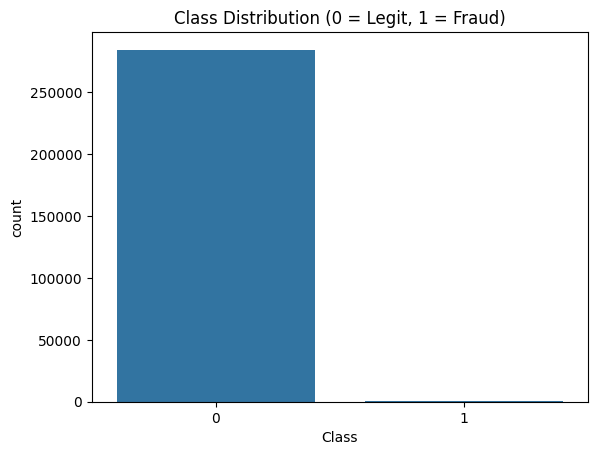

In [4]:
sns.countplot(x="Class", data=data)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

In [5]:
scaler = StandardScaler()
data["Amount"] = scaler.fit_transform(data[["Amount"]])
data["Time"] = scaler.fit_transform(data[["Time"]])

In [6]:
data["Hour"] = (data["Time"] * 24) % 24
data["Amount_Percentile"] = data["Amount"].rank(pct=True)

In [7]:
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_smote))

Before SMOTE: [227428    417]
After SMOTE : [227428 227428]


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=5.85,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [ ]:
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42
)

lgb_model.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 227428, number of negative: 227428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 454856, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_smote, y_train_smote)

CatBoostClassifier(depth=8, iterations=300, learning_rate=0.05, random_state=42, verbose=0)

In [ ]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

lgb_pred = lgb_model.predict(X_test)
cat_pred = cat_model.predict(X_test)

In [ ]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

In [ ]:
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")
evaluate(y_test, lgb_pred, "LightGBM")
evaluate(y_test, cat_pred, "CatBoost")


Random Forest
Accuracy : 0.9989817773252344
Precision: 0.5825242718446602
Recall   : 0.8
F1 Score : 0.6741573033707865

XGBoost
Accuracy : 0.9995435553526912
Precision: 0.8769230769230769
Recall   : 0.76
F1 Score : 0.8142857142857143

LightGBM
Accuracy : 0.9994908886626171
Precision: 0.8382352941176471
Recall   : 0.76
F1 Score : 0.7972027972027972

CatBoost
Accuracy : 0.999385555282469
Precision: 0.7702702702702703
Recall   : 0.76
F1 Score : 0.7651006711409396


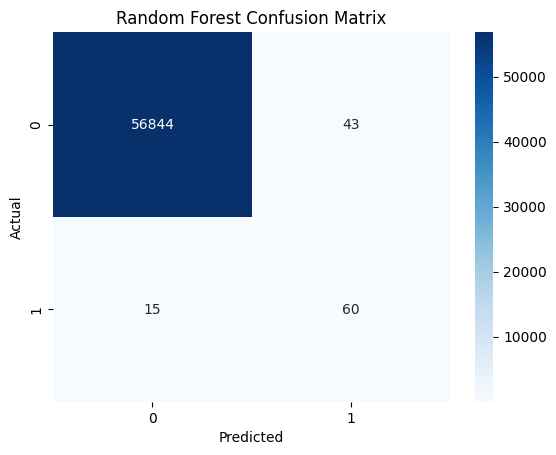

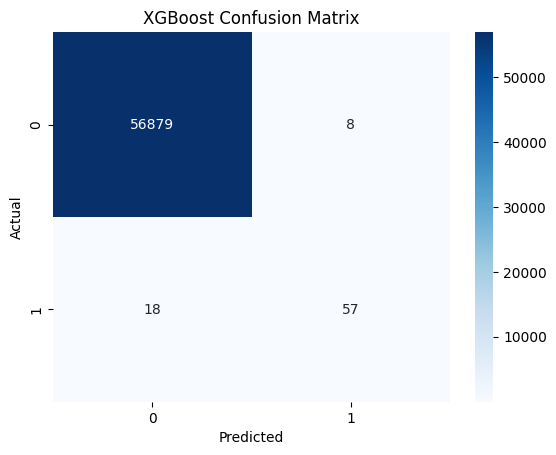

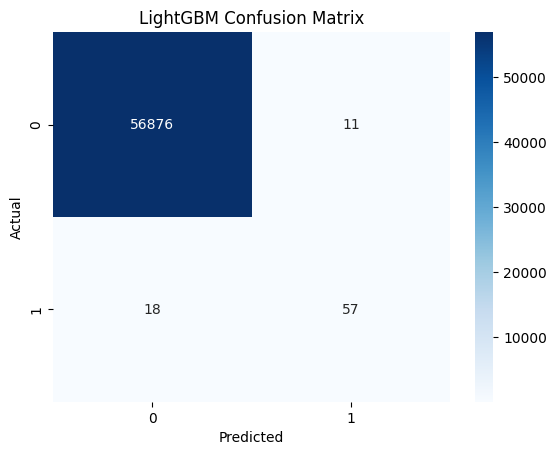

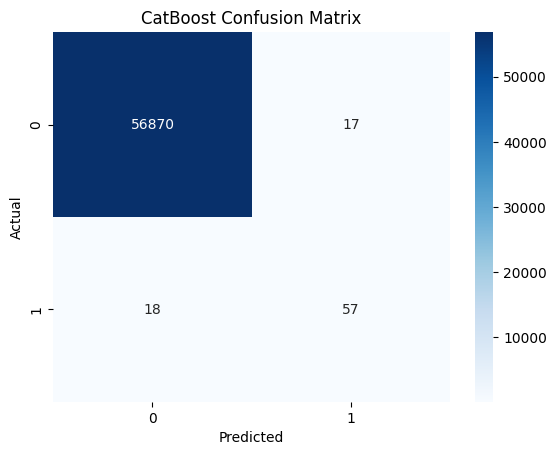

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, rf_pred, "Random Forest Confusion Matrix")
plot_cm(y_test, xgb_pred, "XGBoost Confusion Matrix")
plot_cm(y_test, lgb_pred, "LightGBM Confusion Matrix")
plot_cm(y_test, cat_pred, "CatBoost Confusion Matrix")

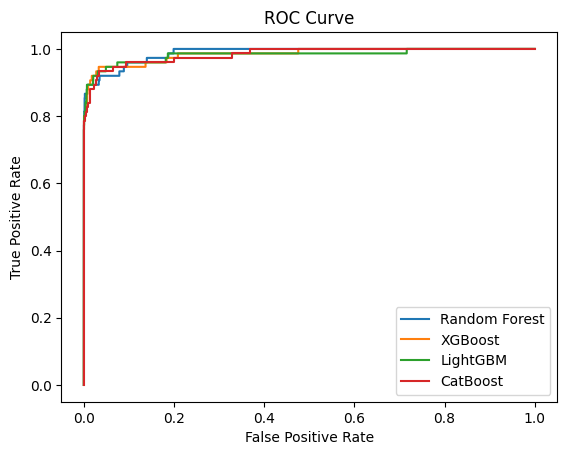

In [ ]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
cat_probs = cat_model.predict_proba(X_test)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_probs)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probs)

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot(lgb_fpr, lgb_tpr, label="LightGBM")
plt.plot(cat_fpr, cat_tpr, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

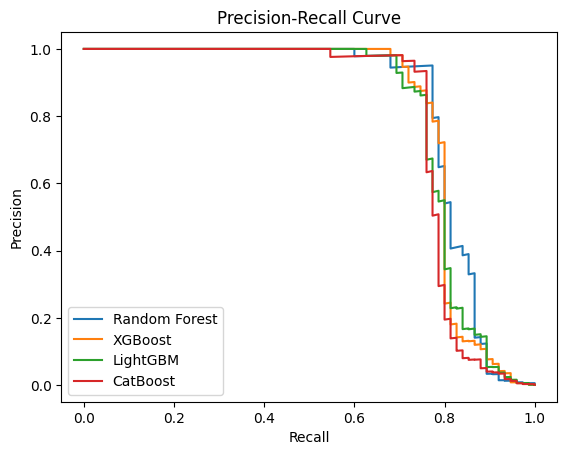

In [ ]:
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_probs)
lgb_prec, lgb_rec, _ = precision_recall_curve(y_test, lgb_probs)
cat_prec, cat_rec, _ = precision_recall_curve(y_test, cat_probs)

plt.plot(rf_rec, rf_prec, label="Random Forest")
plt.plot(xgb_rec, xgb_prec, label="XGBoost")
plt.plot(lgb_rec, lgb_prec, label="LightGBM")
plt.plot(cat_rec, cat_prec, label="CatBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

In [ ]:
def find_best_threshold(y_true, y_prob, fn_cost=5, fp_cost=1):
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_t = 0.5
    min_cost = float("inf")

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = (fn * fn_cost) + (fp * fp_cost)

        if cost < min_cost:
            min_cost = cost
            best_t = t

    return best_t, min_cost

In [ ]:
rf_best_t, _ = find_best_threshold(y_test, rf_probs)
xgb_best_t, _ = find_best_threshold(y_test, xgb_probs)
lgb_best_t, _ = find_best_threshold(y_test, lgb_probs)
cat_best_t, _ = find_best_threshold(y_test, cat_probs)

print("RF Best Threshold :", rf_best_t)
print("XGB Best Threshold:", xgb_best_t)
print("LGB Best Threshold:", lgb_best_t)
print("CAT Best Threshold:", cat_best_t)

RF Best Threshold : 0.66
XGB Best Threshold: 0.24000000000000002
LGB Best Threshold: 0.54
CAT Best Threshold: 0.74


In [ ]:
rf_opt_pred = (rf_probs >= rf_best_t).astype(int)
xgb_opt_pred = (xgb_probs >= xgb_best_t).astype(int)
lgb_opt_pred = (lgb_probs >= lgb_best_t).astype(int)
cat_opt_pred = (cat_probs >= cat_best_t).astype(int)

evaluate(y_test, rf_opt_pred, "RF Optimized")
evaluate(y_test, xgb_opt_pred, "XGB Optimized")
evaluate(y_test, lgb_opt_pred, "LGB Optimized")
evaluate(y_test, cat_opt_pred, "CAT Optimized")


RF Optimized
Accuracy : 0.9996488887328394
Precision: 0.9508196721311475
Recall   : 0.7733333333333333
F1 Score : 0.8529411764705882

XGB Optimized
Accuracy : 0.9994382219725431
Precision: 0.7866666666666666
Recall   : 0.7866666666666666
F1 Score : 0.7866666666666666

LGB Optimized
Accuracy : 0.9995259997893332
Precision: 0.8636363636363636
Recall   : 0.76
F1 Score : 0.8085106382978723

CAT Optimized
Accuracy : 0.9996137776061234
Precision: 0.9344262295081968
Recall   : 0.76
F1 Score : 0.8382352941176471



Hybrid RF + XGB + LGB + CAT
Accuracy : 0.999420666409185
Precision: 0.7692307692307693
Recall   : 0.8
F1 Score : 0.7843137254901961


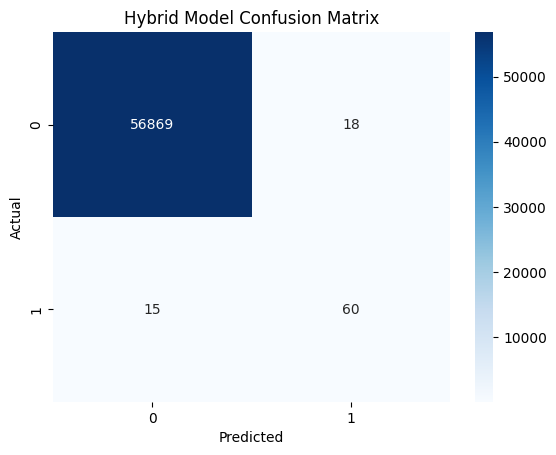

In [ ]:
hybrid_pred = np.where(
    (rf_opt_pred == 1) |
    (xgb_opt_pred == 1) |
    (lgb_opt_pred == 1) |
    (cat_opt_pred == 1),
    1,
    0
)

evaluate(y_test, hybrid_pred, "Hybrid RF + XGB + LGB + CAT")
plot_cm(y_test, hybrid_pred, "Hybrid Model Confusion Matrix")

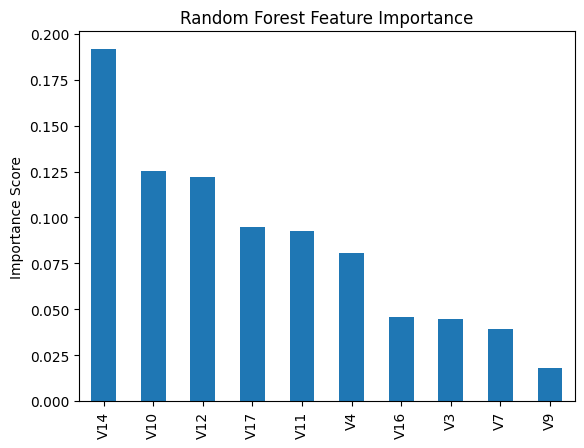

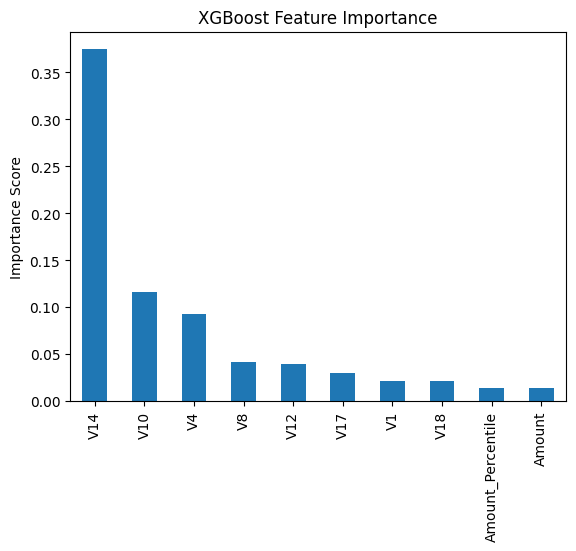

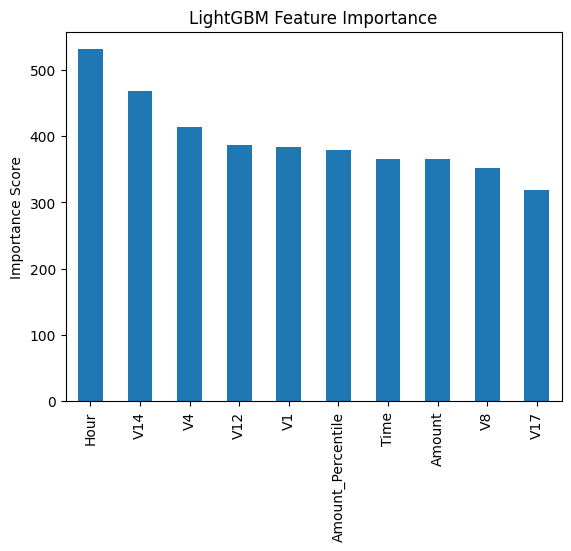

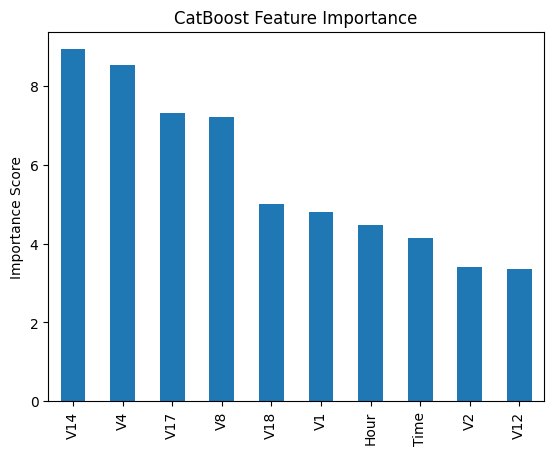

In [ ]:
# Feature Importance – Random Forest
rf_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

rf_imp.plot(kind="bar", title="Random Forest Feature Importance")
plt.ylabel("Importance Score")
plt.show()


# Feature Importance – XGBoost
xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

xgb_imp.plot(kind="bar", title="XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.show()


# Feature Importance – LightGBM
lgb_imp = pd.Series(
    lgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

lgb_imp.plot(kind="bar", title="LightGBM Feature Importance")
plt.ylabel("Importance Score")
plt.show()


# Feature Importance – CatBoost
cat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)[:10]

cat_imp.plot(kind="bar", title="CatBoost Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
import pickle

# Save Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save XGBoost model
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save LightGBM model
with open("lightgbm_model.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

# Save CatBoost model
with open("catboost_model.pkl", "wb") as f:
    pickle.dump(cat_model, f)


# Save hybrid thresholds
hybrid_config = {
    "rf_threshold": rf_best_t,
    "xgb_threshold": xgb_best_t,
    "lgb_threshold": lgb_best_t,
    "cat_threshold": cat_best_t
}

with open("hybrid_thresholds.pkl", "wb") as f:
    pickle.dump(hybrid_config, f)


print("Models saved successfully:")
print("random_forest_model.pkl")
print("xgboost_model.pkl")
print("lightgbm_model.pkl")
print("catboost_model.pkl")
print("hybrid_thresholds.pkl")

Models saved successfully:
random_forest_model.pkl
xgboost_model.pkl
lightgbm_model.pkl
catboost_model.pkl
hybrid_thresholds.pkl


In [ ]:
# Model Accuracy Comparison Table

rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
lgb_acc = accuracy_score(y_test, lgb_pred)
cat_acc = accuracy_score(y_test, cat_pred)
hybrid_acc = accuracy_score(y_test, hybrid_pred)

results_table = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Hybrid Model"
    ],
    "Accuracy": [
        rf_acc,
        xgb_acc,
        lgb_acc,
        cat_acc,
        hybrid_acc
    ]
})

results_table.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,XGBoost,0.999544
2,LightGBM,0.999491
4,Hybrid Model,0.999421
3,CatBoost,0.999386
0,Random Forest,0.998982


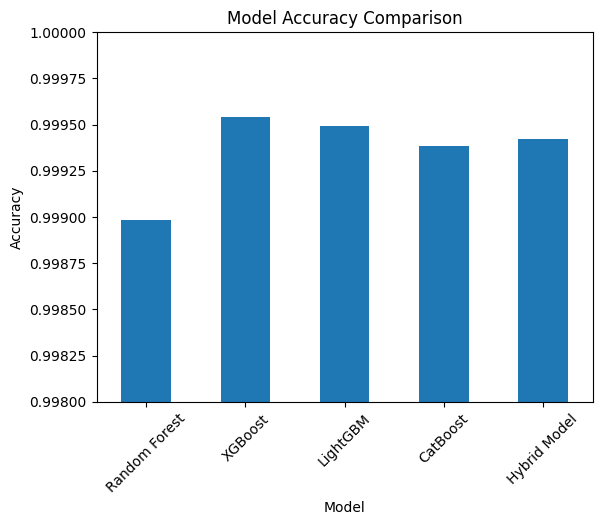

In [ ]:
results_table.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    title="Model Accuracy Comparison"
)

plt.ylabel("Accuracy")
plt.ylim(0.998, 1.0)   # zoom the axis
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Full Model Performance Comparison

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

lgb_precision = precision_score(y_test, lgb_pred)
lgb_recall = recall_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred)

cat_precision = precision_score(y_test, cat_pred)
cat_recall = recall_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)

hyb_precision = precision_score(y_test, hybrid_pred)
hyb_recall = recall_score(y_test, hybrid_pred)
hyb_f1 = f1_score(y_test, hybrid_pred)

performance_table = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Hybrid Model"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred),
        accuracy_score(y_test, cat_pred),
        accuracy_score(y_test, hybrid_pred)
    ],
    "Precision": [
        rf_precision,
        xgb_precision,
        lgb_precision,
        cat_precision,
        hyb_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall,
        lgb_recall,
        cat_recall,
        hyb_recall
    ],
    "F1 Score": [
        rf_f1,
        xgb_f1,
        lgb_f1,
        cat_f1,
        hyb_f1
    ]
})

performance_table.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,XGBoost,0.999544,0.876923,0.76,0.814286
2,LightGBM,0.999491,0.838235,0.76,0.797203
4,Hybrid Model,0.999421,0.769231,0.80,0.784314
3,CatBoost,0.999386,0.770270,0.76,0.765101
0,Random Forest,0.998982,0.582524,0.80,0.674157


In [ ]:
# Hybrid Prediction Function (Single Transaction)

import pickle
import numpy as np
import pandas as pd

def hybrid_predict(transaction_df):
    """
    transaction_df : pandas DataFrame with SAME columns as training data (X)
    returns: prediction (0 = Legit, 1 = Fraud)
    """

    # Load models
    with open("random_forest_model.pkl", "rb") as f:
        rf_model = pickle.load(f)

    with open("xgboost_model.pkl", "rb") as f:
        xgb_model = pickle.load(f)

    with open("lightgbm_model.pkl", "rb") as f:
        lgb_model = pickle.load(f)

    with open("catboost_model.pkl", "rb") as f:
        cat_model = pickle.load(f)

    with open("hybrid_thresholds.pkl", "rb") as f:
        thresholds = pickle.load(f)


    rf_t = thresholds["rf_threshold"]
    xgb_t = thresholds["xgb_threshold"]
    lgb_t = thresholds["lgb_threshold"]
    cat_t = thresholds["cat_threshold"]


    # Probability predictions
    rf_prob = rf_model.predict_proba(transaction_df)[:, 1][0]
    xgb_prob = xgb_model.predict_proba(transaction_df)[:, 1][0]
    lgb_prob = lgb_model.predict_proba(transaction_df)[:, 1][0]
    cat_prob = cat_model.predict_proba(transaction_df)[:, 1][0]


    # Apply thresholds
    rf_decision = 1 if rf_prob >= rf_t else 0
    xgb_decision = 1 if xgb_prob >= xgb_t else 0
    lgb_decision = 1 if lgb_prob >= lgb_t else 0
    cat_decision = 1 if cat_prob >= cat_t else 0


    # Hybrid rule (OR logic)
    final_decision = 1 if (
        rf_decision == 1 or
        xgb_decision == 1 or
        lgb_decision == 1 or
        cat_decision == 1
    ) else 0


    return {
        "RandomForest_Probability": rf_prob,
        "XGBoost_Probability": xgb_prob,
        "LightGBM_Probability": lgb_prob,
        "CatBoost_Probability": cat_prob,
        "Final_Hybrid_Prediction": final_decision
    }

In [ ]:
# Test hybrid prediction with one sample from test set

import pickle

sample_txn = X_test.iloc[[0]]

# Align input features to what the saved model was trained on
with open("random_forest_model.pkl", "rb") as f:
    rf_saved = pickle.load(f)

expected_cols = list(rf_saved.feature_names_in_)

sample_txn_aligned = sample_txn.reindex(columns=expected_cols, fill_value=0)

# Run hybrid prediction
result = hybrid_predict(sample_txn_aligned)

print("Hybrid Prediction Result:")
print(result)

Hybrid Prediction Result:
{'RandomForest_Probability': np.float64(0.014411801525464993), 'XGBoost_Probability': np.float32(1.214014e-05), 'LightGBM_Probability': np.float64(3.569709042082849e-05), 'CatBoost_Probability': np.float64(4.4496041657256e-07), 'Final_Hybrid_Prediction': 0}
